# Try yourself for HITS, SVD <a class="tocSkip">

In [1]:
import numpy as np
np.set_printoptions(precision=2)

# Compute Hubs and Authorities for the graph below

In [2]:
A = [[0,1,1,1,0],[1,0,0,1,0],[0,0,0,0,1],[0,1,1,0,0],[0,0,0,0,0]]

In [3]:
h=[1,1,1,1,1]

In [4]:
h=[0,0,1,0,0]

In [5]:
AT=np.transpose(A)
print (np.dot(A, AT))

[[3 1 0 2 0]
 [1 2 0 0 0]
 [0 0 1 0 0]
 [2 0 0 2 0]
 [0 0 0 0 0]]


In [6]:
a=np.dot(h,A)
print (a)

[0 0 0 0 1]


In [7]:
h=np.dot (a,AT)
print (h)

[0 0 1 0 0]


## Try yourself, step by step, using Hub and Authority updates in alternation
 * Try to normalize
 * Also start from ``h=[0,0,1,0,0]``
 * Also compare with the power method below

In [8]:
hh=np.dot(np.linalg.matrix_power(np.dot(A,AT),10),[1,1,1,1,1])

In [9]:
hh

array([8057274, 2886989,       1, 5772954,       0])

In [10]:
np.dot(hh,A)

array([ 2886989, 13830228, 13830228, 10944263,        1])

# Compare results with SVD

Understand first, second, ..., hub-authority vector pairs

In [11]:
U, w, V = np.linalg.svd(A, full_matrices=True)
W = np.diag(w)
print ("First Hub vector is", U[:,0])

First Hub vector is [0.78 0.28 0.   0.56 0.  ]


In [12]:
w

array([2.19, 1.41, 1.  , 0.46, 0.  ])

In [13]:
U

array([[ 7.80e-01, -3.33e-16,  0.00e+00,  6.25e-01,  0.00e+00],
       [ 2.80e-01,  8.94e-01,  0.00e+00, -3.49e-01,  0.00e+00],
       [ 0.00e+00,  0.00e+00,  1.00e+00,  0.00e+00,  0.00e+00],
       [ 5.59e-01, -4.47e-01,  0.00e+00, -6.98e-01,  0.00e+00],
       [ 0.00e+00, -0.00e+00,  0.00e+00,  0.00e+00,  1.00e+00]])

In [14]:
V

array([[ 0.13,  0.61,  0.61,  0.48, -0.  ],
       [ 0.63, -0.32, -0.32,  0.63,  0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  1.  ],
       [-0.76, -0.16, -0.16,  0.6 , -0.  ],
       [ 0.  , -0.71,  0.71,  0.  ,  0.  ]])

In [15]:
U[:,2]

array([0., 0., 1., 0., 0.])

In [16]:
print ("2nd Hub vector is", U[:,1])

2nd Hub vector is [-3.33e-16  8.94e-01  0.00e+00 -4.47e-01 -0.00e+00]


In [17]:
w

array([2.19, 1.41, 1.  , 0.46, 0.  ])

In [18]:
V[2,:]

array([0., 0., 0., 0., 1.])

We should (up to rounding errors) get back

``array([[0, 1, 1, 1, 0],
         [1, 0, 0, 1, 0],
         [0, 0, 0, 0, 1],
         [0, 1, 1, 0, 0],
         [0, 0, 0, 0, 0]])``

In [19]:
print (np.dot(U, np.dot(W, V)))

[[-5.55e-17  1.00e+00  1.00e+00  1.00e+00  0.00e+00]
 [ 1.00e+00 -1.11e-16 -1.11e-16  1.00e+00  0.00e+00]
 [ 0.00e+00  0.00e+00  0.00e+00  0.00e+00  1.00e+00]
 [ 0.00e+00  1.00e+00  1.00e+00  0.00e+00  0.00e+00]
 [ 0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00]]


# Path counting

 * Find the best, second best HITS hubs and authorities. Record the node rank order.
 * Repeat with ``L[5,4] = 1`` instead of ``L[4,5] = 1`` and compare.

In [20]:
L = np.zeros((10,10))
L[0:5,0:5] = 1
L[5:10,5:10] = 1
L[4,5] = 1
L

array([[1., 1., 1., 1., 1., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 1., 1., 1., 1., 1.]])

In [21]:
U,w,V = np.linalg.svd(L)

In [22]:
w

array([5.12e+00, 4.91e+00, 7.95e-01, 2.01e-16, 9.48e-17, 2.06e-18,
       5.62e-47, 0.00e+00, 0.00e+00, 0.00e+00])

In [23]:
-U[:,0]

array([0.3 , 0.3 , 0.3 , 0.3 , 0.38, 0.31, 0.31, 0.31, 0.31, 0.31])

In [24]:
-V[0,:]

array([0.31, 0.31, 0.31, 0.31, 0.31, 0.38, 0.3 , 0.3 , 0.3 , 0.3 ])

In [25]:
print(-U[:,1])

[ 0.32  0.32  0.32  0.32  0.27 -0.32 -0.32 -0.32 -0.32 -0.32]


In [26]:
-V[1,:]

array([ 0.32,  0.32,  0.32,  0.32,  0.32, -0.27, -0.32, -0.32, -0.32,
       -0.32])

# Spectral partitioning
 * Compute the Laplace matrix
 * Compute SVD
 * Find the partitioning by Fiedler vector U[:,n-1].
 * Plot pairs of singular vectors as above.
 * Find other partitions by higher order singular vectors. What is U[:,n]? Why?

In [27]:
A=[[0,0.8,0.6,0,0.1,0],
   [0.8,0,0.8,0,0,0],
   [0.6,0.8,0,0.2,0,0],
   [0,0,0.2,0,0.8,0.7],
   [0.1,0,0,0.8,0,0.8],
   [0,0,0,0.7,0.8,0]]
np.sum(A,1)

array([1.5, 1.6, 1.6, 1.7, 1.7, 1.5])

In [28]:
U,w,V=np.linalg.svd(np.diag(np.sum(A,1))-A)
print (np.diag(np.sum(A,1))-A)
print ()
print (U)
print ()
print (w)
print ()
print (V)

[[ 1.5 -0.8 -0.6  0.  -0.1  0. ]
 [-0.8  1.6 -0.8  0.   0.   0. ]
 [-0.6 -0.8  1.6 -0.2  0.   0. ]
 [ 0.   0.  -0.2  1.7 -0.8 -0.7]
 [-0.1  0.   0.  -0.8  1.7 -0.8]
 [ 0.   0.   0.  -0.7 -0.8  1.5]]

[[-0.11 -0.38 -0.31 -0.65 -0.41  0.41]
 [-0.22  0.71  0.3   0.01 -0.44  0.41]
 [ 0.37 -0.39  0.04  0.64 -0.37  0.41]
 [-0.61 -0.   -0.45  0.34  0.37  0.41]
 [ 0.65  0.35 -0.3  -0.17  0.41  0.41]
 [-0.09 -0.29  0.72 -0.18  0.45  0.41]]

[2.57e+00 2.47e+00 2.29e+00 2.08e+00 1.88e-01 2.22e-16]

[[-0.11 -0.22  0.37 -0.61  0.65 -0.09]
 [-0.38  0.71 -0.39 -0.    0.35 -0.29]
 [-0.31  0.3   0.04 -0.45 -0.3   0.72]
 [-0.65  0.01  0.64  0.34 -0.17 -0.18]
 [-0.41 -0.44 -0.37  0.37  0.41  0.45]
 [-0.41 -0.41 -0.41 -0.41 -0.41 -0.41]]


# Sample visualization with singular vector pairs from U

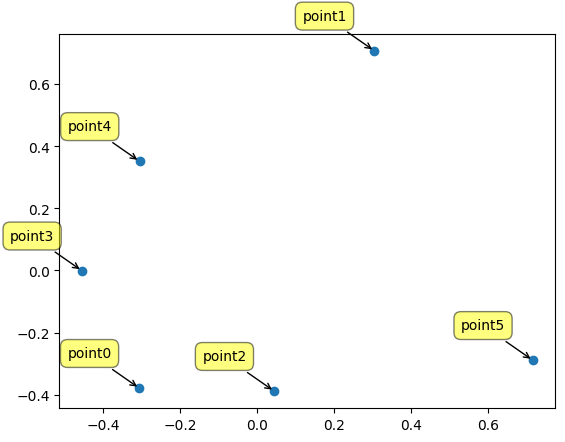

In [29]:
# Scatter plot of pairs of singular vectors
X = U[:,2]
Y = U[:,1]
%matplotlib inline
import matplotlib.pyplot as plt
N, _ = np.shape(U)
labels = ['point{0}'.format(i) for i in range(N)]
plt.subplots_adjust(bottom = 0.1)
plt.scatter(X, Y, marker = 'o')
for label, x, y in zip(labels, X, Y):
    plt.annotate(
        label, 
        xy = (x, y), xytext = (-20, 20),
        textcoords = 'offset points', ha = 'right', va = 'bottom',
        bbox = dict(boxstyle = 'round,pad=0.5', fc = 'yellow', alpha = 0.5),
        arrowprops = dict(arrowstyle = '->', connectionstyle = 'arc3,rad=0'))

plt.show()

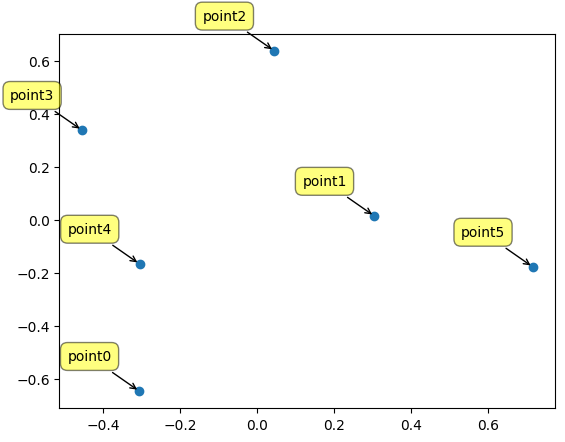

In [30]:
# Scatter plot of pairs of singular vectors
X = U[:,2]
Y = U[:,3]
%matplotlib inline
import matplotlib.pyplot as plt
N, _ = np.shape(U)
labels = ['point{0}'.format(i) for i in range(N)]
plt.subplots_adjust(bottom = 0.1)
plt.scatter(X, Y, marker = 'o')
for label, x, y in zip(labels, X, Y):
    plt.annotate(
        label, 
        xy = (x, y), xytext = (-20, 20),
        textcoords = 'offset points', ha = 'right', va = 'bottom',
        bbox = dict(boxstyle = 'round,pad=0.5', fc = 'yellow', alpha = 0.5),
        arrowprops = dict(arrowstyle = '->', connectionstyle = 'arc3,rad=0'))

plt.show()

# With NetworkX

In [31]:
import networkx as nx

In [32]:
G=nx.from_numpy_array(np.matrix(A))

In [33]:
def plot_graph_2D (G,X,Y):   
    layout = dict(zip(list(G.nodes),zip(X,Y)))
    nx.draw(G, with_labels=True, pos=layout, width=0.5)
    nx.draw_networkx_edges(G, pos=layout, arrows=True, arrowsize=20)
    plt.show()

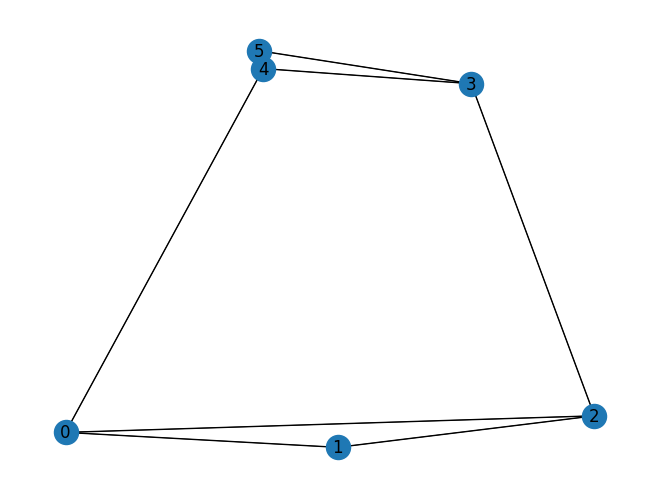

In [34]:
plot_graph_2D (G, U[:,3], U[:,4])

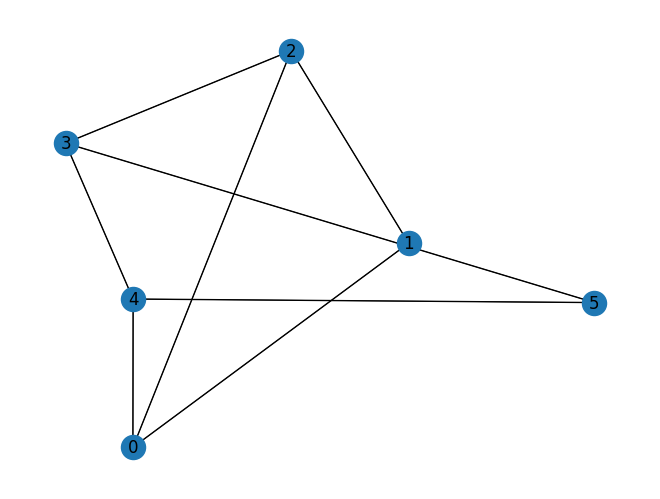

In [35]:
plot_graph_2D (G, U[:,2], U[:,3])